<a href="https://colab.research.google.com/github/yasseen116/Software-Defect-predection-Project/blob/main/DS_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("SoftwareDefectDataset.csv")
df.head()

,LOC,CYCLO,LENGTH,VOLUME,DIFFICULTY,INT_FAN_IN,INT_FAN_OUT,NUM_OPERATORS,NUM_OPERANDS,BRANCH_COUNT,DEFECT_LABEL
0,0.779239,0.478261,0.274048,0.544918,0.564121,0.222222,0.444444,0.736196,0.807377,0.642857,0
1,0.595156,0.608696,0.742561,0.758597,0.450649,0.222222,0.000000,0.576687,0.200820,0.142857,0
2,0.895502,0.000000,0.968166,0.754277,0.672996,1.000000,0.000000,0.116564,0.020492,0.000000,1
3,0.782007,0.565217,0.164706,0.017766,0.584106,0.000000,1.000000,0.615542,0.481557,0.500000,0
4,0.757785,0.217391,0.560900,0.126125,0.526050,0.555556,0.222222,0.656442,0.655738,0.857143,1


In [ ]:
df.shape

(60000, 23)

In [12]:
# Basic description of Dataset
df.describe(include='all')

,LOC,CYCLO,LENGTH,VOLUME,DIFFICULTY,INT_FAN_IN,INT_FAN_OUT,NUM_OPERATORS,NUM_OPERANDS,BRANCH_COUNT,DEFECT_LABEL
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.520711,0.493304,0.509783,0.505971,0.502349,0.503556,0.510667,0.493988,0.512625,0.514643,0.326000
std,0.289402,0.301158,0.289705,0.291389,0.284572,0.315975,0.321400,0.295131,0.276572,0.314337,0.468982
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.278720,0.217391,0.255017,0.252619,0.262725,0.222222,0.222222,0.231084,0.280738,0.214286,0.000000
50%,0.531834,0.478261,0.513841,0.522552,0.511328,0.555556,0.555556,0.494888,0.517418,0.571429,0.000000
75%,0.767474,0.739130,0.761678,0.759446,0.750681,0.777778,0.777778,0.756646,0.742828,0.785714,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
# Add missing values to 5% of rows in selected columns

df.loc[df.sample(frac=0.05, random_state=42).index, 'LOC'] = np.nan
df.loc[df.sample(frac=0.05, random_state=7).index, 'CYCLO'] = np.nan

df.isnull().sum()

,0
LOC,50
CYCLO,50
LENGTH,0
VOLUME,0
DIFFICULTY,0
INT_FAN_IN,0
INT_FAN_OUT,0
NUM_OPERATORS,0
NUM_OPERANDS,0
BRANCH_COUNT,0


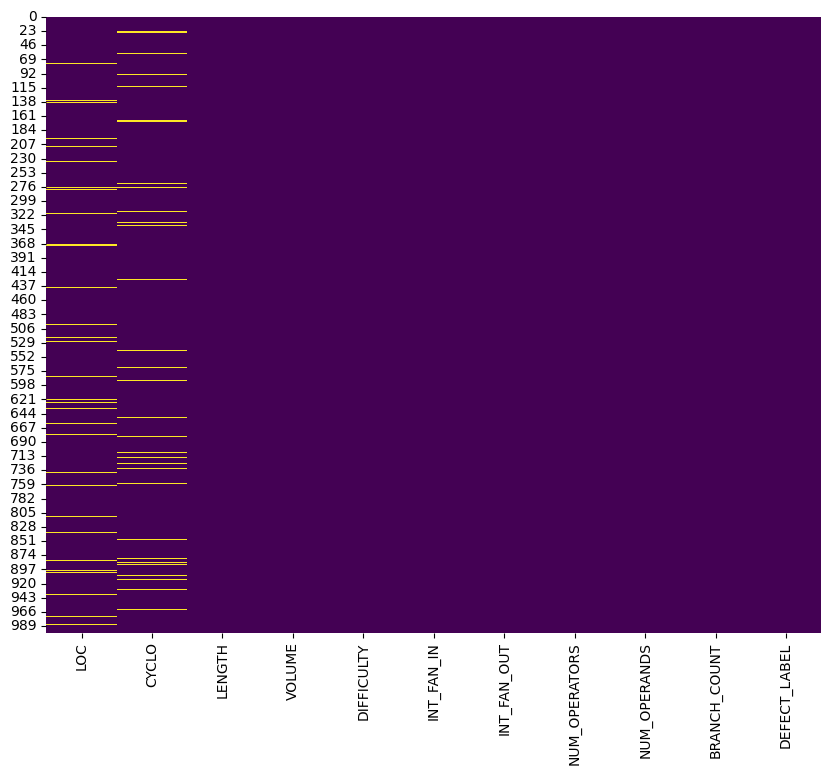

In [34]:
plt.figure(figsize= (10,8))
#heatmap of missing values
sns.heatmap(df.isnull(),cbar= False,cmap="viridis")
plt.show()


In [35]:
# Removing / handling missing values for all feature columns

feature_cols = [
    "LOC",
    "CYCLO",
    "LENGTH",
    "VOLUME",
    "DIFFICULTY",
    "INT_FAN_IN",
    "INT_FAN_OUT",
    "NUM_OPERATORS",
    "NUM_OPERANDS",
    "BRANCH_COUNT"
]

for col in feature_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
LOC,0
CYCLO,0
LENGTH,0
VOLUME,0
DIFFICULTY,0
INT_FAN_IN,0
INT_FAN_OUT,0
NUM_OPERATORS,0
NUM_OPERANDS,0
BRANCH_COUNT,0


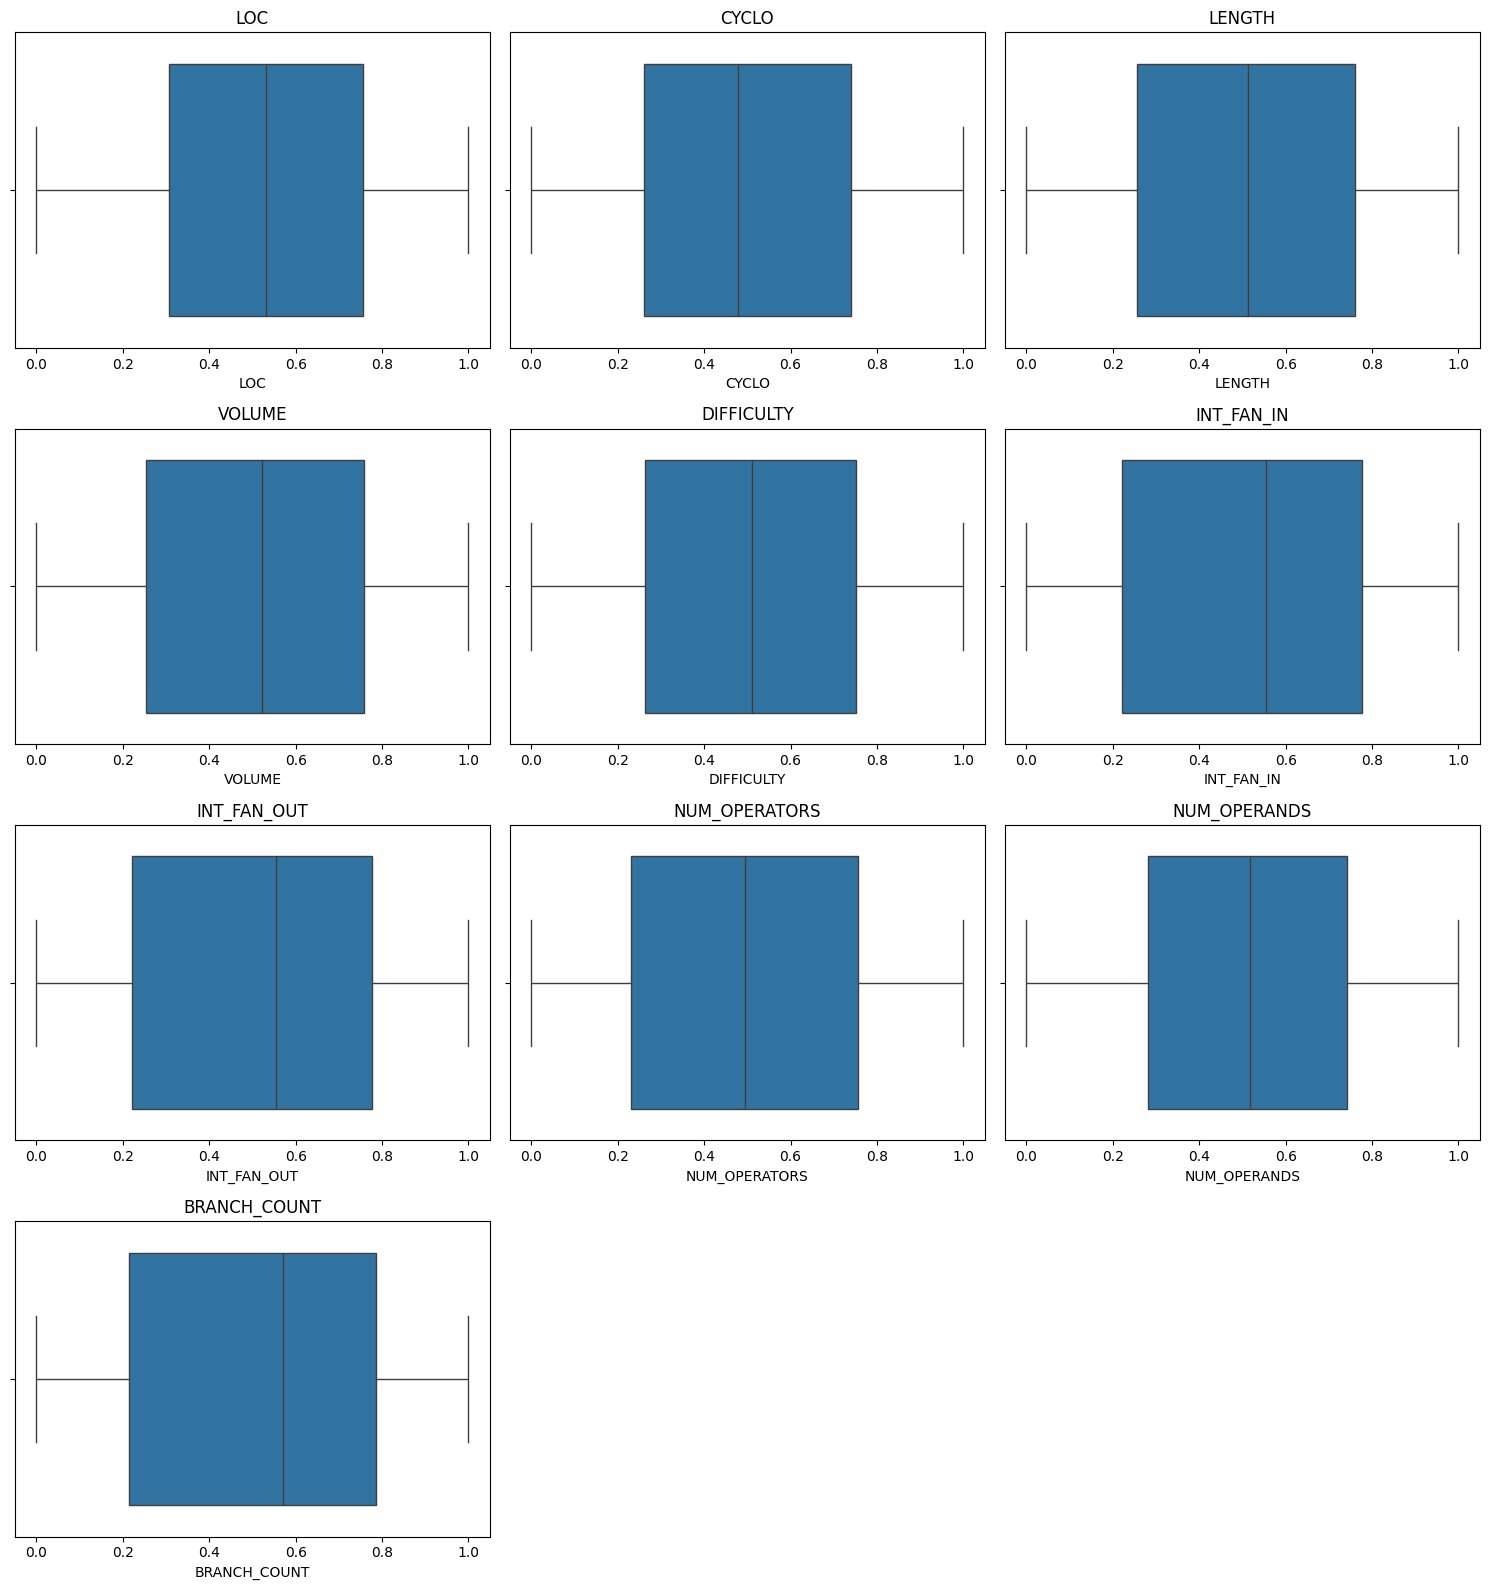

In [37]:
# BOXPLOTS FOR ALL NUMERIC COLUMNS (checking for outliers)

cols = [col for col in df.select_dtypes(include=["int64", "float64"]).columns if col != "DEFECT_LABEL"]

n_cols = 3  # number of plots per row
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

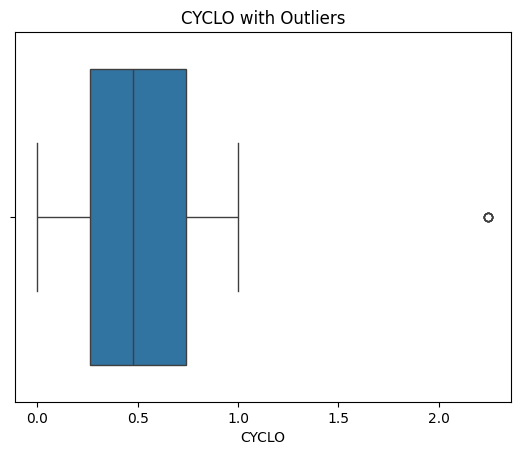

In [38]:
# ADD OUTLIERS TO ONE COLUMN

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_outliers = df.copy()

# Choose one feature column from the dataset
col = "CYCLO"

# Add 5 extreme high values
indices = np.random.choice(df_outliers.index, size=5, replace=False)

df_outliers.loc[indices, col] = (
    df_outliers[col].mean() + 6 * df_outliers[col].std()
)

# Plot
sns.boxplot(x=df_outliers[col])
plt.title(f"{col} with Outliers")
plt.show()

Outliers fixed!


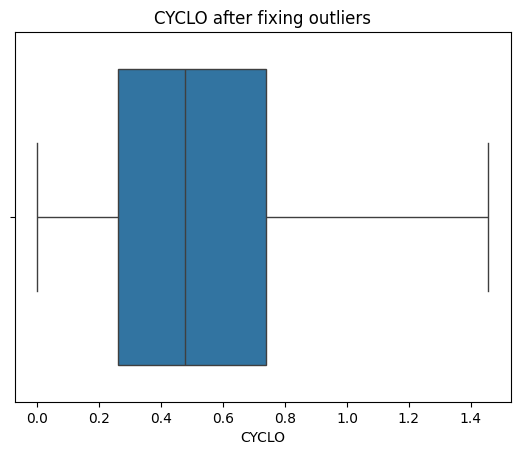

In [39]:
# FIX OUTLIERS USING IQR (CLIPPING)

import seaborn as sns
import matplotlib.pyplot as plt

df_fixed = df_outliers.copy()

# Choose the same column where outliers were added
col = "CYCLO"

# Calculate IQR
Q1 = df_fixed[col].quantile(0.25)
Q3 = df_fixed[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Clip values outside the lower and upper bounds
df_fixed[col] = df_fixed[col].clip(lower=lower, upper=upper)

print("Outliers fixed!")

# Plot after fixing
sns.boxplot(x=df_fixed[col])
plt.title(f"{col} after fixing outliers")
plt.show()

In [40]:
#amount of duplicates
print(df.duplicated().sum())


0


In [ ]:
## scaling dataset
# Separate features and target
X = df.drop("defect", axis=1)
y = df["defect"]

# Scale ONLY numerical features in X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.select_dtypes(include=["int64", "float64"]))

# Put scaled data back into X
X[X.select_dtypes(include=["int64", "float64"]).columns] = X_scaled

# Combine back
df = pd.concat([X, y], axis=1)

df.head()

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,-1.134527,-0.927257,-1.619419,1.027780,1.672362,0.134220,1.652792,-0.866131,-1.473760,-1.596958,...,-0.570538,-1.223211,0.139580,0.134379,-1.517877,-1.125399,-1.588222,0.453128,0.753340,1
1,0.904378,-1.139839,1.692608,0.784958,-0.001497,0.290079,-0.254076,0.125750,-0.281286,0.930130,...,1.384018,0.172047,0.801121,-0.148519,-0.378205,-0.081287,-0.657735,0.937198,1.676728,1
2,0.428260,-0.360372,-0.015700,1.478736,-1.098163,0.321251,-1.640888,-0.370191,1.409017,1.345541,...,0.886495,0.172047,-1.427230,0.417278,-1.448806,-0.429325,1.224072,-0.169248,-0.978012,1
3,-1.410395,0.985979,-0.834991,1.027780,-0.694128,-1.452081,0.439331,1.613571,-1.554802,-1.718119,...,1.010875,1.567304,-0.939778,-0.926491,-0.205528,-1.299418,0.626893,-0.030942,-0.285471,1
4,1.362292,0.135652,1.082498,0.889025,-0.520970,1.446901,0.786034,-1.610041,0.158656,0.168542,...,1.188562,-0.874396,1.184119,-1.138664,-0.309134,-1.125399,-0.956324,-0.376707,-1.439706,1


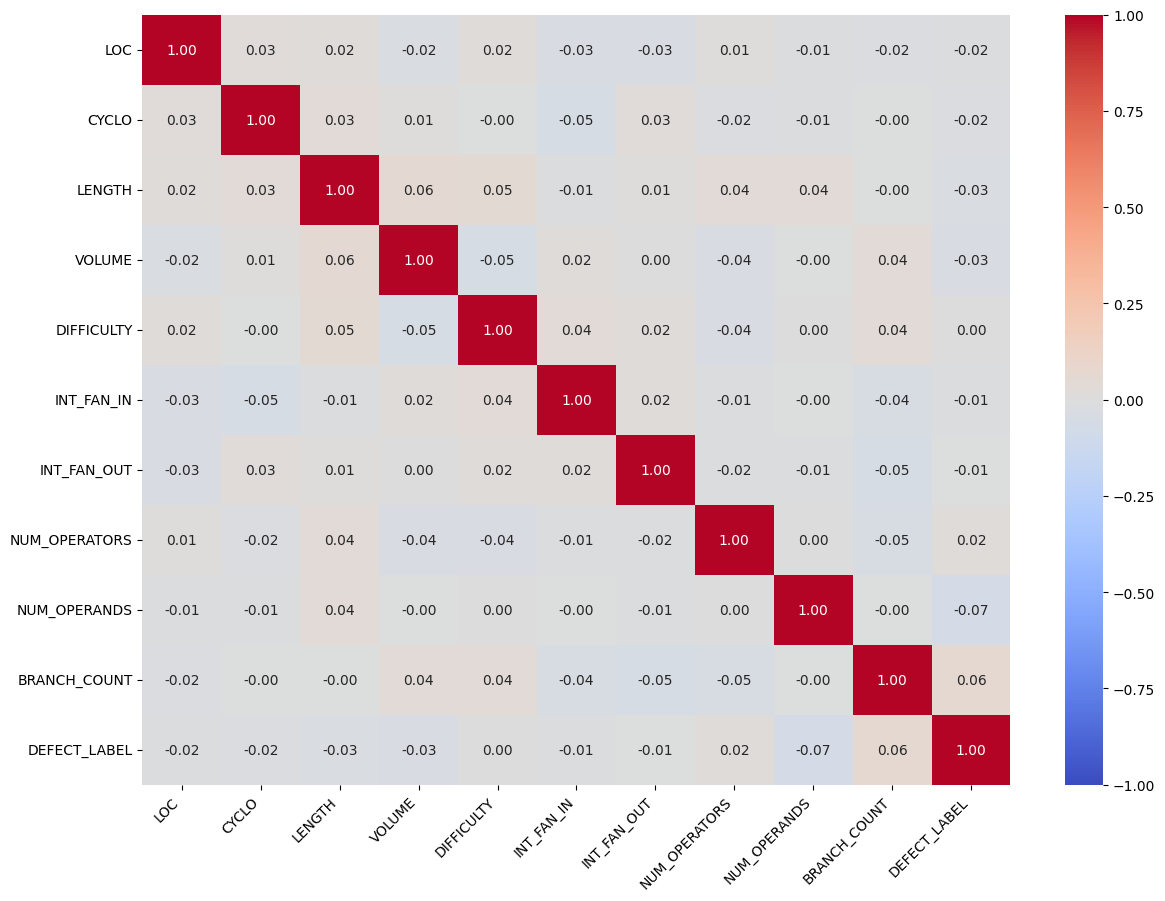

In [42]:
# Correlation heatmap with numbers

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("DEFECT_LABEL", axis=1)
y = df["DEFECT_LABEL"]

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

LOC              0.122218
VOLUME           0.120255
LENGTH           0.119475
NUM_OPERATORS    0.118066
NUM_OPERANDS     0.115866
DIFFICULTY       0.113820
CYCLO            0.088077
BRANCH_COUNT     0.078573
INT_FAN_IN       0.064239
INT_FAN_OUT      0.059411
dtype: float64


In [44]:
# Select features based on the importance values you already got
selected_features = importances[importances > 0.02].index

# Create a new dataset with only the selected features and the target column
df_selected = df[selected_features.tolist() + ["DEFECT_LABEL"]]

# Show the selected features and the new dataset shape
print("Selected features:", list(selected_features))
print("Original shape:", df.shape)
print("Reduced shape:", df_selected.shape)

df_selected.head()

Selected features: ['LOC', 'CYCLO', 'LENGTH', 'VOLUME', 'DIFFICULTY', 'INT_FAN_IN', 'INT_FAN_OUT', 'NUM_OPERATORS', 'NUM_OPERANDS', 'BRANCH_COUNT']
Original shape: (1000, 11)
Reduced shape: (1000, 11)


,LOC,CYCLO,LENGTH,VOLUME,DIFFICULTY,INT_FAN_IN,INT_FAN_OUT,NUM_OPERATORS,NUM_OPERANDS,BRANCH_COUNT,DEFECT_LABEL
0,0.779239,0.478261,0.274048,0.544918,0.564121,0.222222,0.444444,0.736196,0.807377,0.642857,0
1,0.595156,0.608696,0.742561,0.758597,0.450649,0.222222,0.000000,0.576687,0.200820,0.142857,0
2,0.895502,0.000000,0.968166,0.754277,0.672996,1.000000,0.000000,0.116564,0.020492,0.000000,1
3,0.782007,0.565217,0.164706,0.017766,0.584106,0.000000,1.000000,0.615542,0.481557,0.500000,0
4,0.757785,0.217391,0.560900,0.126125,0.526050,0.555556,0.222222,0.656442,0.655738,0.857143,1


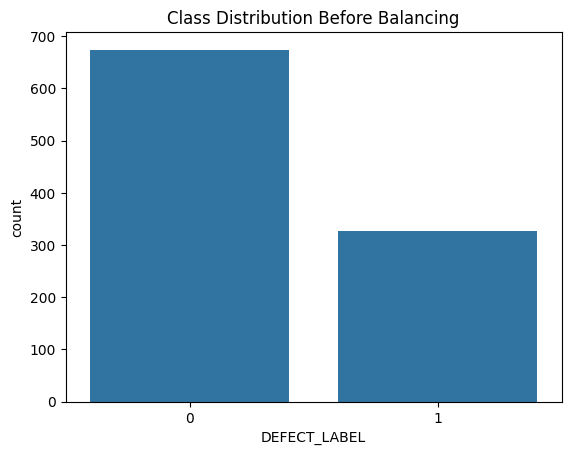

In [45]:
# Plot the class distribution before balancing
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="DEFECT_LABEL", data=df_selected)
plt.title("Class Distribution Before Balancing")
plt.show()

In [46]:
# Balance the dataset by oversampling the minority class
from sklearn.utils import resample
import pandas as pd

df_majority = df_selected[df_selected["DEFECT_LABEL"] == 1]
df_minority = df_selected[df_selected["DEFECT_LABEL"] == 0]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled]).sample(frac=1, random_state=42)

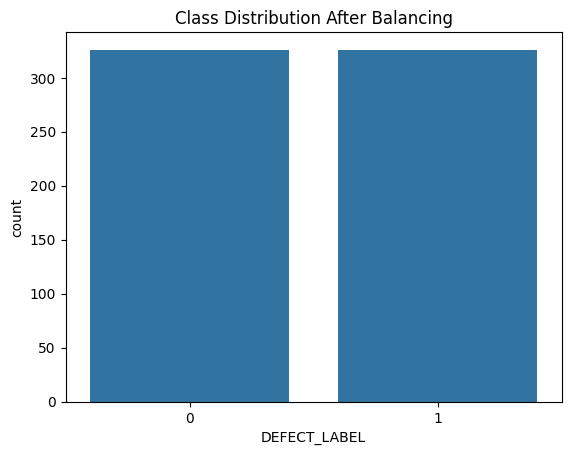

In [47]:
# Plot the class distribution after balancing
sns.countplot(x="DEFECT_LABEL", data=df_balanced)
plt.title("Class Distribution After Balancing")
plt.show()

In [49]:
# Import Decision Tree and evaluation tools
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split balanced features and target
X = df_balanced.drop("DEFECT_LABEL", axis=1)
y = df_balanced["DEFECT_LABEL"]

# Split data into training and testing sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict target values for the test set
y_pred = dt_model.predict(X_test)

# Print model evaluation results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6641221374045801

Confusion Matrix:
 [[42 24]
 [20 45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.64      0.66        66
           1       0.65      0.69      0.67        65

    accuracy                           0.66       131
   macro avg       0.66      0.66      0.66       131
weighted avg       0.66      0.66      0.66       131

